In [1]:
import tmm

from numpy import pi, linspace, inf, array
import numpy as np
import math
from scipy.interpolate import interp1d
from scipy.integrate import quad
from scipy.signal import hilbert
import time
import matplotlib.pyplot as plt
%matplotlib inline

degree = pi/180

In [2]:
# generate nk for spatial KK stack

nb = 1.7

def triangular(x, a, b):
    if (x >= 0 and x < b):
        return -a/b*(x-b)
    elif (x < 0 and x > -b):
        return a/b*(x+b)
    else:
        return 0

In [36]:
def generate_n_and_d(a, gam):

    xq = linspace(-200*gam, 200*gam, 10000)
    func = np.zeros_like(xq)

    for i, x in enumerate (xq):
        func[i] = triangular(x, a, gam)

    eq = interp1d(xq,func,kind='nearest')
    Hx = hilbert(eq(xq))
    
    xq2 = np.concatenate((linspace(0,10*gam,100), linspace(10*gam,50*gam,60) , linspace(50*gam,200*gam,40)))
    xq2 = np.unique(np.concatenate((-xq2 , xq2)))
    x0 = int(len(xq2)/2)-50
    xf = int(len(xq2)/2)+50

    d_list = np.diff(xq2)
    d_list[-1] = inf
    d_list[0] = inf

    eq2 = interp1d(xq,Hx,kind='nearest')
    diel = -np.imag(eq2(xq2[:-1])) + nb**2 + 1j*np.real(eq2(xq2[:-1]))
    for i, d in enumerate(diel):
        print(f"angle at element {i} is: {np.round(np.angle(d)*180/pi, 2)}, imag is: {np.imag(d)}, real is: {np.real(d)}")
    n_list = np.sqrt(-np.imag(eq2(xq2[:-1])) + nb**2 + 1j*np.real(eq2(xq2[:-1])))
    #n_list = np.abs(np.real(n_list)) + np.abs(np.imag(n_list))*1j
    n_list[-1] = nb
    n_list[0] = nb

    for i, n in enumerate(np.imag(n_list)):
        if n < -0.01:
            print(f"Imaginary n is 0 at element {i} !!!")

    plt.figure(3)
    plt.plot(range(len(xq2[x0:xf])), -np.imag(eq2(xq2[x0:xf])) + nb**2, label='real')
    plt.plot(range(len(xq2[x0:xf])), np.real(eq2(xq2[x0:xf])), label='imag')
    plt.legend()

    plt.figure(4)
    plt.plot(range(len(xq2[x0:xf])), np.imag(n_list[x0:xf]), label='imag')
    plt.plot(range(len(xq2[x0:xf])), np.real(n_list[x0:xf]), label='real')
    plt.legend()


    return (d_list, n_list)

def generate_x_from_d(d_list):
    x_list = np.zeros(len(d_list)+1)
    curr = 0
    for i, thickness in enumerate(d_list):
        x_list[i+1] = curr + thickness
        curr = x_list[i+1]
    return x_list

def TRA_func(d_list, n_list):
    pol = 'p'
    lambda_list = np.linspace(2,5,100)
    angle = 0
    T_list_LR = np.zeros_like(lambda_list)
    R_list_LR = np.zeros_like(lambda_list)
    A_list_LR = np.zeros_like(lambda_list)
    T_list_RL = np.zeros_like(lambda_list)
    R_list_RL = np.zeros_like(lambda_list)
    A_list_RL = np.zeros_like(lambda_list)
    for j, lamb in enumerate(lambda_list):
        T_list_LR[j] = tmm.coh_tmm(pol, n_list, d_list, angle, lamb)['T']
        R_list_LR[j] = tmm.coh_tmm(pol, n_list, d_list, angle, lamb)['R']
        A_list_LR[j] = 1 - T_list_LR[j] - R_list_LR[j]

        T_list_RL[j] = tmm.coh_tmm_reverse(pol, n_list, d_list, angle, lamb)['T']
        R_list_RL[j] = tmm.coh_tmm_reverse(pol, n_list, d_list, angle, lamb)['R']
        A_list_RL[j] = 1 - T_list_RL[j] - R_list_RL[j]

    return (T_list_LR, R_list_LR, A_list_LR, T_list_RL, R_list_RL, A_list_RL)

angle at element 0 is: -0.0, imag is: -3.637978807091713e-16, real is: 2.890015728548076
angle at element 1 is: 0.0, imag is: 5.115907697472722e-17, real is: 2.893032315976303
angle at element 2 is: 0.0, imag is: 1.091393642127514e-15, real is: 2.896054428287552
angle at element 3 is: 0.0, imag is: 1.3642420526593925e-16, real is: 2.8990876020734517
angle at element 4 is: -0.0, imag is: -2.931316823007211e-16, real is: 2.902169287576978
angle at element 5 is: -0.0, imag is: -5.771313892622189e-16, real is: 2.905241824438777
angle at element 6 is: 0.0, imag is: 5.570655048359185e-16, real is: 2.908342751685393
angle at element 7 is: 0.0, imag is: 2.9756713428786597e-16, real is: 2.9114781934475182
angle at element 8 is: 0.0, imag is: 5.882621635484645e-16, real is: 2.9146545382561895
angle at element 9 is: 0.0, imag is: 4.0125572411180017e-16, real is: 2.917878493587261
angle at element 10 is: 0.0, imag is: 1.4822199573497079e-15, real is: 2.921157145820794
angle at element 11 is: -0.0,

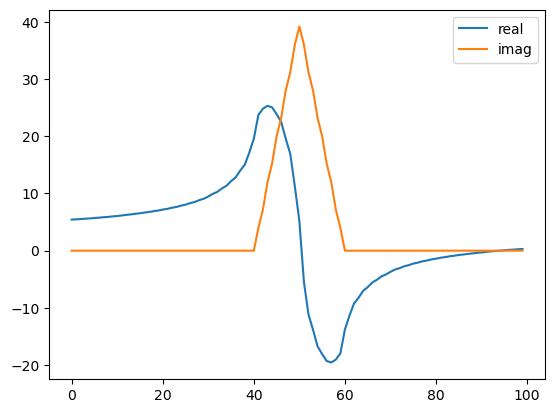

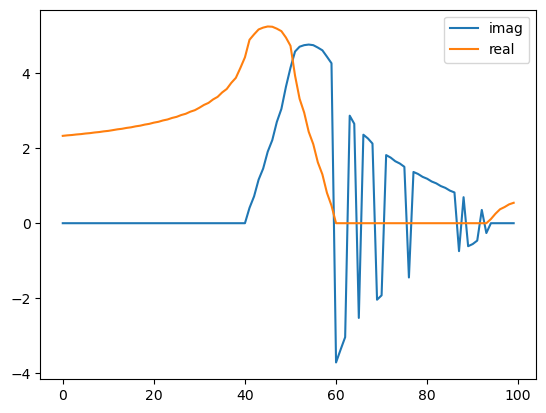

In [37]:
n_list, d_list = generate_n_and_d(40, 0.06)

In [ ]:
# FoM KK and bulk calculations sweeping over amplitude and width of diel

gam_list = np.linspace(0.001, 0.1, num=100)
A_list = np.linspace(0, 50, num=100)
length_A = len(A_list)

x0 = 0
xf = 100
y0 = 0
yf = 100
FOM_bulk = np.zeros((xf-x0, yf-y0))
FOM_KK = np.zeros((xf-x0, yf-y0))

start = time.time()
for i, gam in enumerate(gam_list[x0 : xf]):
    for j, A in enumerate(A_list[y0 : yf]):
        d_list, n_list = generate_n_and_d(A, gam)
        (T_list_LR, R_list_LR, A_list_LR, T_list_RL, R_list_RL, A_list_RL) = TRA_func(d_list, n_list)
        lambda_list = np.linspace(2,5,100)
        delta_lamb = lambda_list[-1] - lambda_list[0]
        
        x_list = generate_x_from_d(d_list[1:-1])
        losses_total = np.trapz(np.imag(n_list[:-1]), x=x_list)
        trans_bulk = np.exp(-4*np.pi*losses_total/lambda_list)
        emiss_bulk = 1 - trans_bulk
        FOM_bulk[i][j] = (np.trapz(trans_bulk, x=lambda_list))**2 / np.trapz(emiss_bulk, x=lambda_list) / delta_lamb
        
        FOM_LR = (np.trapz(T_list_LR, x=lambda_list))**2 / np.trapz(A_list_LR, x=lambda_list) / delta_lamb
        FOM_RL = (np.trapz(T_list_RL, x=lambda_list))**2 / np.trapz(A_list_RL, x=lambda_list) / delta_lamb
        FOM_KK[i][j] = max(FOM_LR, FOM_RL)
        print(i*length_A + j)

end = time.time()
print(f"Duration: {end - start} seconds")
np.savetxt("C:\\Users\\kl89\\MS Window Project\\FOM_KK_triangular_vs_Aandgam_fixed.txt", FOM_KK)
np.savetxt("C:\\Users\\kl89\\MS Window Project\\FOM_bulk_triangular_vs_Aandgam_fixed.txt", FOM_bulk)

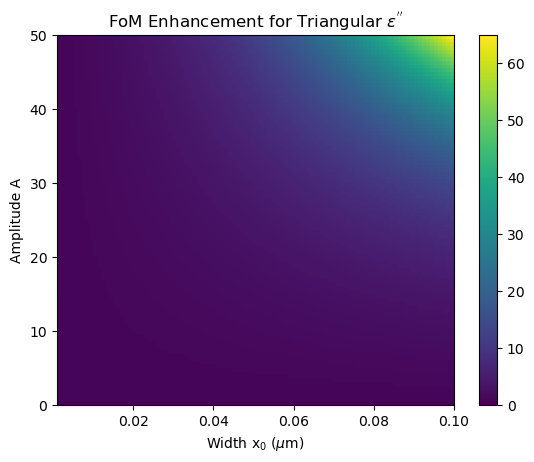

In [19]:
# plot surface plot of FoM enhancement

plt.figure()
plt.imshow((FOM_KK/FOM_bulk).T, interpolation='none', aspect='auto', origin='lower', extent=(gam_list[x0], gam_list[xf-1], A_list[y0], A_list[yf-1]))
plt.ylabel('Amplitude A')
plt.xlabel('Width x$_0$ ($\mu$m)')
plt.title('FoM Enhancement for Triangular $\epsilon^{\'\'}$')
ax = plt.gca()
plt.colorbar()

In [10]:
# calculation at a single A and gamma, to plot TRA.

d_list, n_list = generate_n_and_d(A_list[76], gam_list[86])
x_list = generate_x_from_d(d_list[1:-1])
losses_total = np.trapz(np.imag(n_list[:-1]), x=x_list)

lambda_list = np.linspace(2,5,100)
delta_lamb = lambda_list[-1] - lambda_list[0]
trans_bulk = np.exp(-4*np.pi*losses_total/lambda_list)
emiss_bulk = 1 - trans_bulk
curr_FOM_bulk = (np.trapz(trans_bulk, x=lambda_list))**2 / np.trapz(emiss_bulk, x=lambda_list) / delta_lamb

(T_list_LR, R_list_LR, A_list_LR, T_list_RL, R_list_RL, A_list_RL) = TRA_func(d_list, n_list)

FOM_LR = (np.trapz(T_list_LR, x=lambda_list))**2 / np.trapz(A_list_LR, x=lambda_list) / delta_lamb
FOM_RL = (np.trapz(T_list_RL, x=lambda_list))**2 / np.trapz(A_list_RL, x=lambda_list) / delta_lamb
curr_FOM_KK = max(FOM_LR, FOM_RL)
print(curr_FOM_KK/curr_FOM_bulk)
print(curr_FOM_KK)
print(curr_FOM_bulk)

14.29169396735914


In [ ]:
# plotting TRA from above cell

plt.figure()
plt.plot(lambda_list, T_list_LR, label = 'T_KK')
plt.plot(lambda_list, A_list_LR, label = 'A_KK,LR')
plt.plot(lambda_list, A_list_RL, label = 'A_KK,RL')
plt.plot(lambda_list, trans_bulk, '--', label = 'T_bulk')
plt.plot(lambda_list, emiss_bulk, '--', label = 'A_bulk')
plt.legend(loc='center right')
print(curr_FOM_KK, curr_FOM_bulk)
plt.title('Transmittance and Absorbance (triangular KK)')
plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Fraction of Power')